# Deep Learning: Adult Income Classification

## Objective
Build, train, and evaluate a neural network using TensorFlow/Keras on the UCI Adult (Census Income) dataset.

**Problem:** Predict whether annual income is `<=50K` or `>50K`.

### Workflow
1. Load the same UCI Adult dataset used in previous tasks.
2. Clean missing-value markers and normalize the target.
3. Engineer skewed financial features.
4. Impute, one-hot encode, and standardize the data.
5. Create training, validation, and test sets.
6. Build and train a fully connected Deep Neural Network.
7. Use EarlyStopping and learning-rate reduction to control overfitting.
8. Evaluate with accuracy, precision, recall, F1-score, and ROC-AUC.
9. Generate learning curves, confusion matrix, ROC curve, and architecture information.
10. Discuss challenges, limitations, and improvements.

**Important:** All final performance values in the report must come from the executed notebook.


In [1]:
# Install packages if they are missing
import sys, subprocess, importlib.util

def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

ensure_package("ucimlrepo")
ensure_package("tensorflow")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.21.0
Libraries imported successfully.


In [2]:
# Load UCI Adult dataset
adult = fetch_ucirepo(id=2)
X = adult.data.features.copy()
y = adult.data.targets.copy()

X.columns = X.columns.astype(str).str.strip()
y = y.iloc[:, 0].astype(str).str.strip().str.replace(".", "", regex=False)

print("Dataset shape:", X.shape)
print("\nFeature columns:")
print(list(X.columns))
print("\nTarget distribution:")
print(y.value_counts())


Dataset shape: (48842, 14)

Feature columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [3]:
# Initial inspection
print("Data types:")
print(X.dtypes)

print("\nMissing-value markers before treatment:")
marker_counts = {
    col: X[col].astype(str).str.strip().eq("?").sum()
    for col in X.columns
}
display(pd.Series(marker_counts).sort_values(ascending=False))

print("\nFirst five rows:")
display(X.head())


Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
dtype: object

Missing-value markers before treatment:


occupation        1843
workclass         1836
native-country     583
education            0
fnlwgt               0
age                  0
marital-status       0
education-num        0
race                 0
relationship         0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
dtype: int64


First five rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


## Data Cleaning and Feature Engineering

The `?` marker is converted to NaN. Numerical variables use median imputation and categorical variables use most-frequent imputation. The highly skewed `capital-gain` and `capital-loss` variables are transformed using `log1p`. Preprocessing is fitted only on the training set to reduce data leakage.


In [4]:
# Replace missing-value markers
X = X.replace(r"^\s*\?$", np.nan, regex=True)

numeric_features = [
    "age", "fnlwgt", "education-num",
    "capital-gain", "capital-loss", "hours-per-week"
]
categorical_features = [
    "workclass", "education", "marital-status",
    "occupation", "relationship", "race", "sex", "native-country"
]

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Feature engineering for skewed variables
X["capital-gain"] = np.log1p(X["capital-gain"])
X["capital-loss"] = np.log1p(X["capital-loss"])

# Encode target: >50K = 1, <=50K = 0
y_binary = (y == ">50K").astype(np.float32)

print("Missing cells after marker conversion:", int(X.isna().sum().sum()))
print("Feature matrix shape before encoding:", X.shape)
print("Positive-class proportion:", round(float(y_binary.mean()), 4))


Missing cells after marker conversion: 6465
Feature matrix shape before encoding: (48842, 14)
Positive-class proportion: 0.2393


In [5]:
# Stratified train / validation / test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_binary, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_binary
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_train_val
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

print("\nPositive-class proportions:")
print("Train:", round(float(y_train.mean()), 4))
print("Validation:", round(float(y_val.mean()), 4))
print("Test:", round(float(y_test.mean()), 4))


Training set: (29304, 14) (29304,)
Validation set: (9769, 14) (9769,)
Testing set: (9769, 14) (9769,)

Positive-class proportions:
Train: 0.2393
Validation: 0.2392
Test: 0.2393


In [6]:
# Preprocessing pipeline
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_processed = np.asarray(preprocessor.fit_transform(X_train), dtype=np.float32)
X_val_processed = np.asarray(preprocessor.transform(X_val), dtype=np.float32)
X_test_processed = np.asarray(preprocessor.transform(X_test), dtype=np.float32)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Training NaNs:", np.isnan(X_train_processed).sum())
print("Validation NaNs:", np.isnan(X_val_processed).sum())
print("Testing NaNs:", np.isnan(X_test_processed).sum())


Processed training shape: (29304, 104)
Processed validation shape: (9769, 104)
Processed testing shape: (9769, 104)
Training NaNs: 0
Validation NaNs: 0
Testing NaNs: 0


## Neural Network Architecture

The model is a compact fully connected neural network for tabular data:

**Input → Dense(128, ReLU) → Dropout(0.30) → Dense(64, ReLU) → Dropout(0.20) → Dense(1, Sigmoid)**

ReLU provides nonlinear learning capacity, Dropout helps reduce overfitting, and the sigmoid output produces the probability of the `>50K` class.


In [7]:
# Build and compile the DNN
input_dim = X_train_processed.shape[1]

model = keras.Sequential([
    keras.Input(shape=(input_dim,), name="input"),
    layers.Dense(128, activation="relu", name="dense_128"),
    layers.Dropout(0.30, name="dropout_30"),
    layers.Dense(64, activation="relu", name="dense_64"),
    layers.Dropout(0.20, name="dropout_20"),
    layers.Dense(1, activation="sigmoid", name="output")
], name="Adult_Income_DNN")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "Adult_Income_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,761 (85.00 KB)

 Trainable params: 21,761 (85.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Try to export a network architecture diagram
try:
    keras.utils.plot_model(
        model,
        to_file="adult_income_dnn_architecture.png",
        show_shapes=True,
        show_layer_names=True
    )
    print("Architecture diagram saved successfully.")
except Exception as e:
    print("Automatic diagram export unavailable:", e)
    print("Use the model.summary() output above as the architecture record.")


You must install pydot (`pip install pydot`) for `plot_model` to work.
Architecture diagram saved successfully.


In [9]:
# Train the neural network
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed.")
print("Epochs actually trained:", len(history.history["loss"]))


Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8143 - auc: 0.8473 - loss: 0.3919 - precision: 0.6791 - recall: 0.4243 - val_accuracy: 0.8491 - val_auc: 0.9033 - val_loss: 0.3261 - val_precision: 0.7260 - val_recall: 0.5931 - learning_rate: 0.0010
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8423 - auc: 0.8967 - loss: 0.3347 - precision: 0.7016 - recall: 0.5933 - val_accuracy: 0.8524 - val_auc: 0.9062 - val_loss: 0.3214 - val_precision: 0.7389 - val_recall: 0.5922 - learning_rate: 0.0010
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8492 - auc: 0.9024 - loss: 0.3261 - precision: 0.7178 - recall: 0.6094 - val_accuracy: 0.8536 - val_auc: 0.9072 - val_loss: 0.3195 - val_precision: 0.7426 - val_recall: 0.5939 - learning_rate: 0.0010
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8476 - auc: 0.9034 - loss: 0.3243 - precision: 0.7148 - recall: 0.6044 - val_accuracy: 0.8546 - val_auc: 0.9078 - val_loss: 0.3189 - 

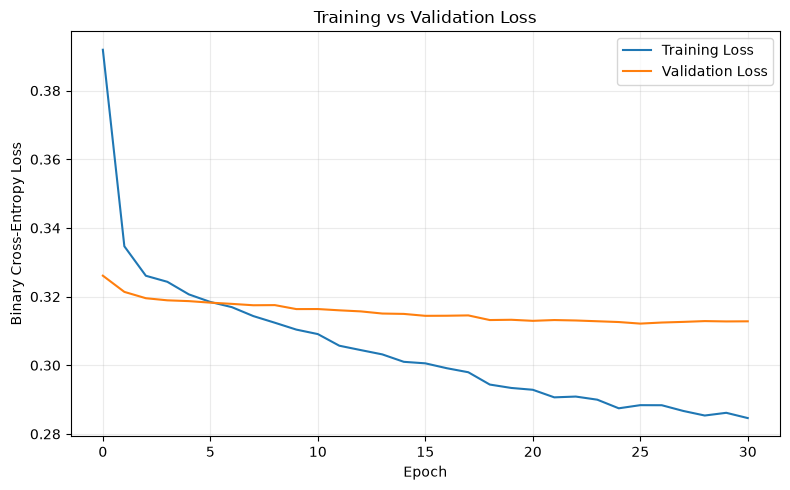

In [10]:
# Training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


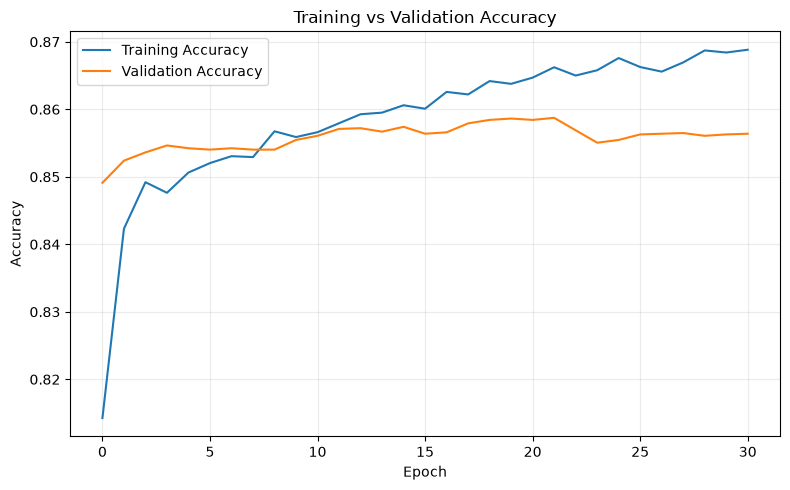

In [11]:
# Training vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [12]:
# Validation performance
val_loss, val_accuracy, val_precision, val_recall, val_auc = model.evaluate(
    X_val_processed, y_val, verbose=0
)

print("Validation Performance")
print(f"Loss:      {val_loss:.4f}")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"ROC-AUC:   {val_auc:.4f}")


Validation Performance
Loss:      0.3121
Accuracy:  0.8563
Precision: 0.7286
Recall:    0.6363
ROC-AUC:   0.9104


In [13]:
# Final test evaluation
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(
    X_test_processed, y_test, verbose=0
)

y_prob = model.predict(X_test_processed, batch_size=1024, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)

print("Final Test Performance")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["<=50K", ">50K"],
    digits=4
))


Final Test Performance
Loss:      0.3125
Accuracy:  0.8585
Precision: 0.7404
Recall:    0.6296
F1-score:  0.6805
ROC-AUC:   0.9103

Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8887    0.9306    0.9092      7431
        >50K     0.7404    0.6296    0.6805      2338

    accuracy                         0.8585      9769
   macro avg     0.8146    0.7801    0.7948      9769
weighted avg     0.8532    0.8585    0.8544      9769



Confusion Matrix:
[[6915  516]
 [ 866 1472]]


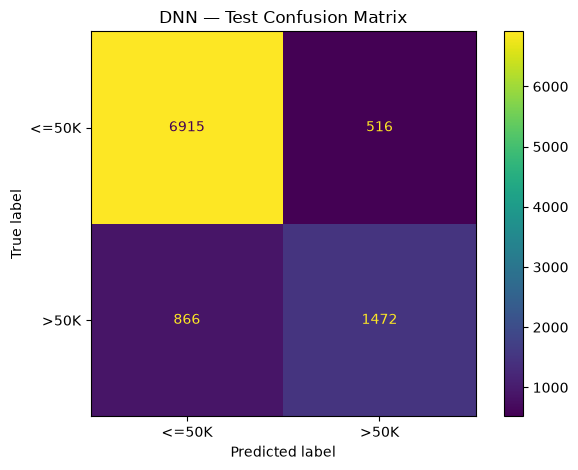

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
).plot()
plt.title("DNN — Test Confusion Matrix")
plt.tight_layout()
plt.show()


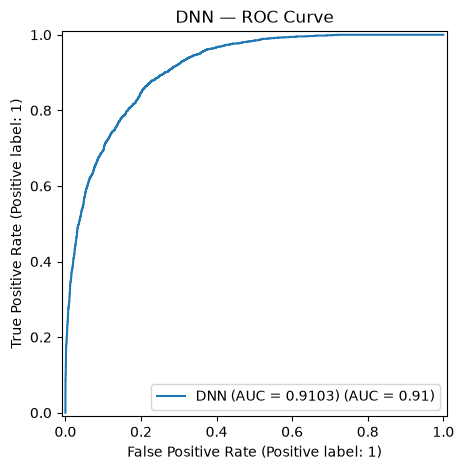

In [15]:
# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f"DNN (AUC = {test_roc_auc:.4f})"
)
plt.title("DNN — ROC Curve")
plt.tight_layout()
plt.show()


In [16]:
# Best validation epoch and training summary
history_df = pd.DataFrame(history.history)
best_idx = history_df["val_loss"].idxmin()

print("Best validation epoch:", int(best_idx) + 1)
print("\nBest validation metrics:")
for col in ["val_loss", "val_accuracy", "val_precision", "val_recall", "val_auc"]:
    print(f"{col}: {history_df.loc[best_idx, col]:.4f}")


Best validation epoch: 26

Best validation metrics:
val_loss: 0.3121
val_accuracy: 0.8563
val_precision: 0.7286
val_recall: 0.6363
val_auc: 0.9104


## Critical Analysis

The final model should be evaluated using accuracy, precision, recall, F1-score and ROC-AUC because the income classes are imbalanced. Training and validation curves should be inspected for signs of overfitting. EarlyStopping restores the best validation-loss weights, while ReduceLROnPlateau lowers the learning rate when validation loss stops improving.

### Challenges
- High-dimensional input after one-hot encoding.
- Class imbalance between income categories.
- Strong skew in financial variables.
- Risk of overfitting in neural networks.
- Greater computational requirements than a simple Logistic Regression baseline.

### Limitations
This is a practical tabular deep-learning baseline. More complex architectures may be tested, but additional complexity does not necessarily improve structured-tabular prediction. Model predictions should also be treated as statistical predictions rather than causal conclusions.


In [17]:
# Final compact summary
print("========== FINAL SUMMARY ==========")
print("Input features after preprocessing:", input_dim)
print("Train / Validation / Test:",
      len(X_train_processed), len(X_val_processed), len(X_test_processed))
print("Epochs trained:", len(history.history["loss"]))
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc_auc:.4f}")
print("===================================")


========== FINAL SUMMARY ==========
Input features after preprocessing: 104
Train / Validation / Test: 29304 9769 9769
Epochs trained: 31
Test Accuracy:  0.8585
Test Precision: 0.7404
Test Recall:    0.6296
Test F1-score:  0.6805
Test ROC-AUC:   0.9103
